In [1]:
from skimage.io import imread
import numpy as np
from scipy.io import loadmat
from matplotlib import pyplot as plt
import time
import lib

In [2]:
rootfolder = '.'

In [3]:
np.random.seed(12345)

Useful function for plot the 2D DCT dictionary

In [4]:
def get_dictionary_img(D):
    M, N = D.shape
    p = int(round(np.sqrt(M)))
    nnn = int(np.ceil(np.sqrt(N)))
    bound = 2
    img = np.ones((nnn*p+bound*(nnn-1), nnn*p+bound*(nnn-1)))
    for i in range(N):
        m = np.mod(i, nnn)
        n = int((i-m)/nnn)
        m = m * p + bound * m
        n = n * p + bound * n
        atom = D[:, i].reshape((p, p))
        if atom.min() < atom.max():
            atom = (atom - atom.min()) / (atom.max() - atom.min())
        img[m: m + p, n: n + p] = atom

    return img

Define a function that implements the OMP

In [5]:
# import from lib

Load the image and rescale it in $[0,1]$

In [6]:
img = imread(f'{rootfolder}/data/peppers256.png') / 255
# img = imread(f'{rootfolder}/data/barbara.png') / 255
# img = imread(f'{rootfolder}/data/Lena512.png') / 255

imsz = img.shape

# patch size
p = 8

# number of elements in the patch
M = p ** 2


Corrupt the image with white gaussian noise

In [7]:
sigma_noise = 20/255
noisy_img = img + sigma_noise * np.random.randn(*img.shape)

Percentage of removed pixel

In [8]:
perc_of_removed_pixels = 0.1

Arbitrarily remove pixels setting them to zero

In [9]:
# create a vector with all the indexes of the image
idx = np.arange(imsz[0] * imsz[1])

# shuffle it and take the target percentage of indexes
idx = np.random.permutation(idx)
zeros = int(perc_of_removed_pixels * imsz[0] * imsz[1])
idx = idx[:zeros]

# the mask is 0 for the chosen idx, 1 elsewhere
msk = np.ones(imsz)
msk.ravel()[idx] = 0

# apply the mask: set to 0 some elements in the noisy image
noisy_img = noisy_img * msk

Compute the psnr of the noisy input

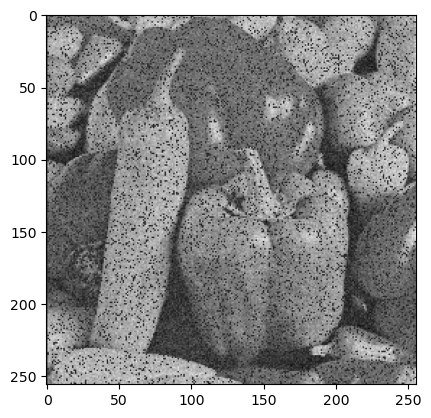

In [10]:
plt.imshow(noisy_img, cmap='gray')

In [11]:
psnr_noisy = lib.get_psnr(img, noisy_img)

Text(0.5, 1.0, 'Dead pixels')

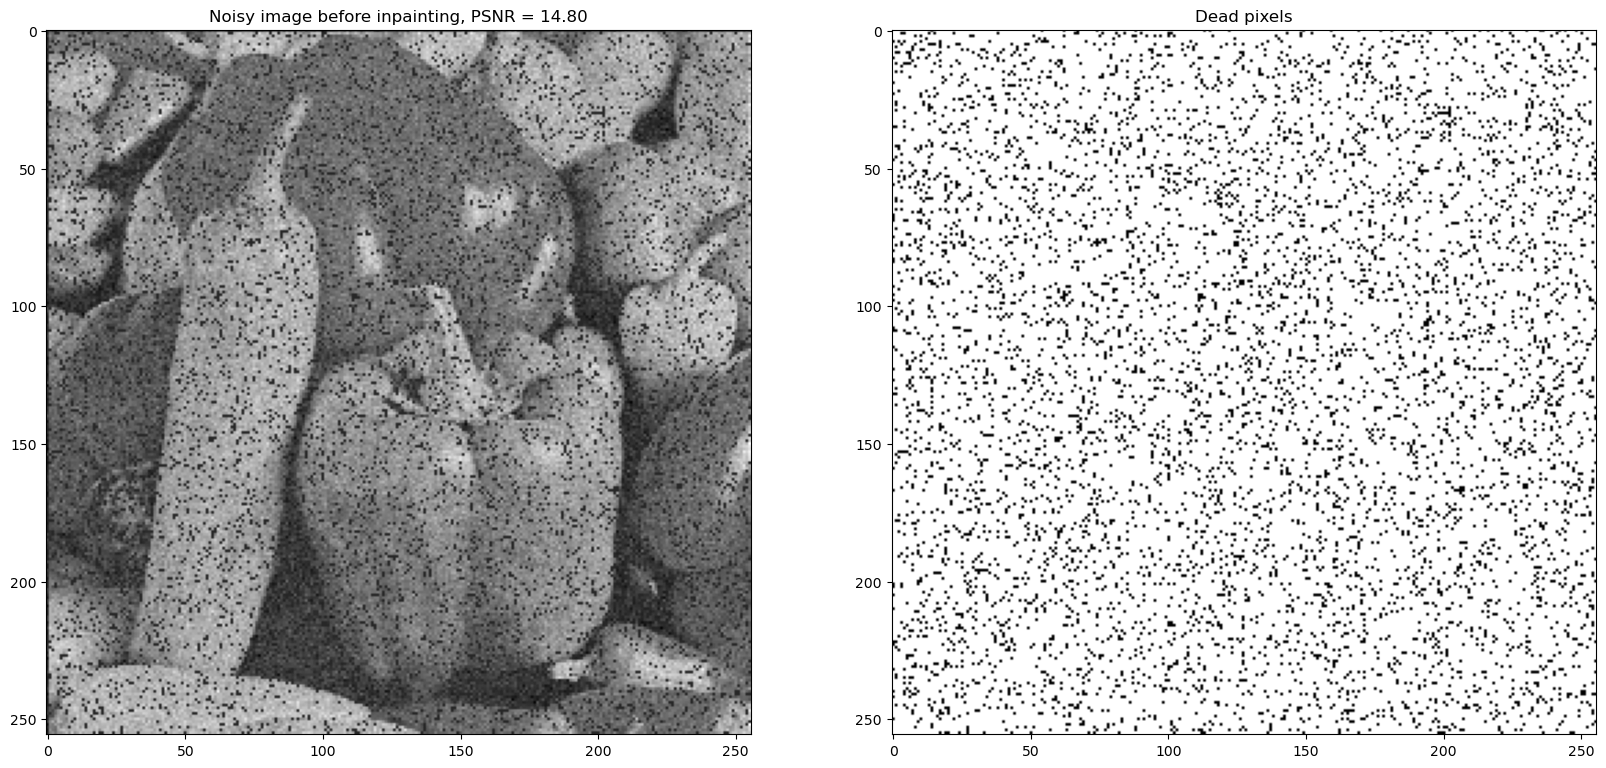

In [12]:
fig, ax = plt.subplots(1, 2, figsize=(20, 10))
ax[0].imshow(noisy_img, cmap='gray')
ax[0].set_title(f'Noisy image before inpainting, PSNR = {psnr_noisy:.2f}')

ax[1].imshow(msk, cmap='gray')
ax[1].set_title(f'Dead pixels')

Load and display the dictionary learned from patches

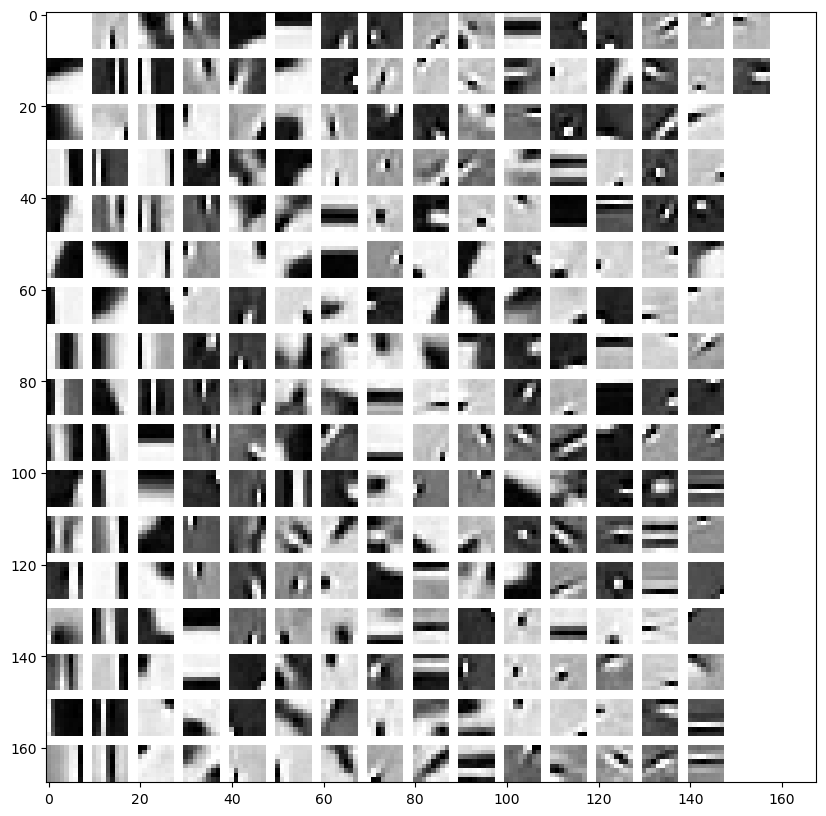

In [13]:
D = loadmat(f'{rootfolder}/data/dict_nat_img.mat')['D']

# add a constant atom to D, KSVD was trained over patches with zero mean - and normalize it
# UPDATE D
D = np.concatenate((np.ones((M, 1)), D), axis=1)

# display the dictionary
D_img = get_dictionary_img(D)

plt.figure(figsize=(10,10))
plt.imshow(D_img, cmap='gray')


Inpainting
----------


In [14]:
# SET stopping criteria of OMP
# orthogonal matching pursuit uses sparsity and errors as stopping criteria
L = M / 2

# initialize the estimated image
img_hat = np.zeros_like(img)

# initialize the weight matrix
weights = np.zeros_like(img)

# define the step (=p for non overlapping paches)
STEP = 4 # STEP = 1 might be very time consuming, start with larger STEP

In [15]:
xs = []

for i in range(0, imsz[0] - p + 1, STEP):
    for j in range(0, imsz[1] - p + 1, STEP):
        # extrach the patch with the top left corner at pixel (ii, jj)
        s = noisy_img[i: i + p, j: j + p]
        s = s.reshape((M, 1))

        # patch extracted from the mask
        m = msk[i: i + p, j: j + p]
        m = m.reshape((M, 1))

        # design the projection operator over the current patch
        proj = np.zeros_like((M, M))
        proj = np.zeros((M, M))
        proj[np.diag_indices(M)] = m.reshape(-1)

        # tau should be proportional to the number of pixels remaining in the patch
        tau = 1.15 * sigma_noise * np.sqrt(np.count_nonzero(m))
        
        # sparse coding w.r.t. PD the inpainted dictionary using L and tau as stopping criteria
        # x = lib.OMP((proj @ s).reshape(-1), proj @ D, L, min_res_norm=tau)
        x = lib.OMP((proj @ s).reshape(-1), proj @ D, L, min_residual_norm=tau)


        xs.append(x)

        # reconstruction: synthesis w.r.t. D the dictionary yielding sparse representation
        s_hat = (D @ x).reshape((p, p))

        # use uniform weights for aggregation
        w = 1

        # put the denoised patch into the estimated image using uniform weights
        # UPDATE img_hat
        img_hat[i: i + p, j: j + p] += s_hat * w

        # store the weight of the current patch in the weight matrix
        # UPDATE weights
        weights[i: i + p, j: j + p] += w
    


/Users/lorenzobenzoni/Documents/university/labs/MMIM/lib.py:79: FutureWarning: `rcond` parameter will change to the default of machine precision times ``max(M, N)`` where M and N are the input matrix dimensions.
To use the future default and silence this warning we advise to pass `rcond=None`, to keep using the old, explicitly pass `rcond=-1`.
  x_OMP = np.linalg.lstsq(D[:, _omega], s)[0]


Normalize the estimated image with the computed weights

In [16]:
img_hat = img_hat / weights

Compute the psnr of the estimated image

Text(0.5, 1.0, 'Estimated Image,\nPSNR = 29.00')

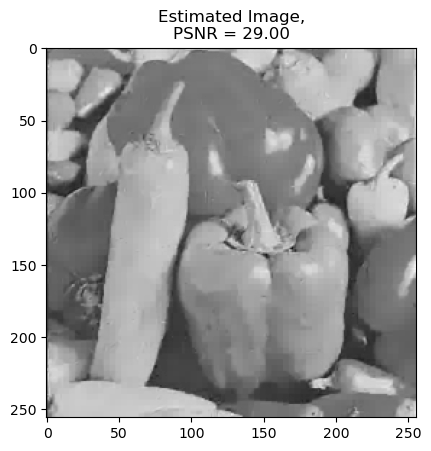

In [17]:
psnr_hat = psnr_noisy = lib.get_psnr(img, img_hat)
plt.figure()
plt.imshow(img_hat, cmap='gray')
plt.title(f'Estimated Image,\nPSNR = {psnr_hat:.2f}')
